# Phase 4: Probabilistic Customer Lifetime Value (LTV)

### Online Retail Customer Analytics — LTV Modeling

Phases 1–3 covered cleaning, RFM segmentation, and a churn classifier. Churn answers *will this customer leave*; this phase answers the complementary question — **how much is a customer worth going forward**, in dollars, over the next 3/6/12 months.

Two models from the `lifetimes` library work together here:
- **BG/NBD (Beta-Geometric/NBD)** — models *when* a customer transacts and estimates the probability they're still an active customer at all, from only their purchase timing (frequency, recency, tenure).
- **Gamma-Gamma** — models *how much* a customer spends per transaction, assuming spend amount is independent of purchase frequency.

Multiplying the two together gives an expected dollar value per customer over a chosen time horizon.

**Notebook structure:**
- **Step 1** — Fit and validate BG/NBD + Gamma-Gamma on the full transaction history
- **Step 2** — Turn the fitted models into an actual 3/6/12-month financial forecast per customer
- **Conclusions** — what the numbers mean and how they could be used

### Setup

Run the cell below once if `lifetimes` isn't already installed.

In [5]:
# !pip install lifetimes --quiet

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from lifetimes.utils import summary_data_from_transaction_data, calibration_and_holdout_data
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.plotting import plot_frequency_recency_matrix, plot_calibration_purchases_vs_holdout_purchases

## Step 1: Probabilistic Modeling — BG/NBD + Gamma-Gamma

### 1.1 Load Transactions

BG/NBD needs the raw per-transaction timestamps to work out each customer's purchase timing — the Phase 2 RFM table (one summarized row per customer) has already thrown that away, so we go back to the cleaned transaction-level data instead.

In [8]:
df = pd.read_parquet('../data/processed/cleaned_online_retail.parquet')
print(f"Successfully loaded dataset with shape: {df.shape}")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

dataset_end_date = df['InvoiceDate'].max()
print(f"Dataset spans {df['InvoiceDate'].min().date()} to {dataset_end_date.date()}")

Successfully loaded dataset with shape: (390565, 12)
Dataset spans 2010-12-01 to 2011-12-09


In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalRevenue,InvoiceMonth,CohortMonth,CohortIndex
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010-12,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010-12,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12,1


### 1.2 Validate BG/NBD via Calibration/Holdout Split

Before trusting BG/NBD for a production forecast, check whether it can actually predict transactions it hasn't seen. The same 90-day boundary from Phase 3 is reused here for consistency, though it's serving a different purpose — forecast validation, not a churn label.


Calibration/Holdout summary: 3,352 customers


,frequency_cal,recency_cal,T_cal,frequency_holdout,duration_holdout
CustomerID,,,,,
12347,4.0,238.0,277.0,2.0,90.0
12348,2.0,110.0,268.0,1.0,90.0
12350,0.0,0.0,220.0,0.0,90.0
12352,3.0,34.0,206.0,3.0,90.0
12353,0.0,0.0,114.0,0.0,90.0


<Figure size 1000x600 with 0 Axes>

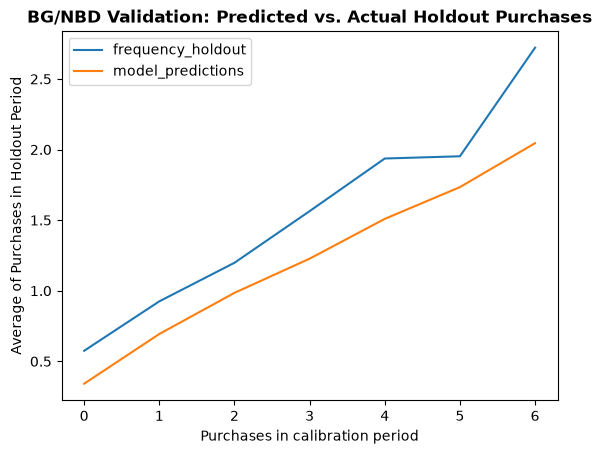

               coef      se(coef)  lower 95% bound  upper 95% bound
r      5.929234e-01  1.950977e-02     5.546842e-01     6.311625e-01
alpha  5.429297e+01  2.217837e+00     4.994601e+01     5.863993e+01
a      5.373449e-22  1.552316e-16    -3.042533e-16     3.042544e-16
b      8.863916e-13  2.559505e-07    -5.016620e-07     5.016638e-07


In [11]:
holdout_days = 90
calibration_end = dataset_end_date - pd.Timedelta(days=holdout_days)

summary_cal_holdout = calibration_and_holdout_data(
    transactions=df,
    customer_id_col='CustomerID',
    datetime_col='InvoiceDate',
    calibration_period_end=calibration_end,
    observation_period_end=dataset_end_date,
    freq='D'
)

print(f"\nCalibration/Holdout summary: {summary_cal_holdout.shape[0]:,} customers")
display(summary_cal_holdout.head())

bgf_validation = BetaGeoFitter(penalizer_coef=0.05)
bgf_validation.fit(
    summary_cal_holdout['frequency_cal'],
    summary_cal_holdout['recency_cal'],
    summary_cal_holdout['T_cal']
)

plt.figure(figsize=(10, 6))
plot_calibration_purchases_vs_holdout_purchases(bgf_validation, summary_cal_holdout)
plt.title('BG/NBD Validation: Predicted vs. Actual Holdout Purchases', fontweight='bold')
plt.show()

print(bgf_validation.summary)

Predicted and actual holdout purchases track closely across most of the frequency range, with more noise at the high-frequency tail where there are simply fewer customers to average over — a normal pattern, not a red flag. This calibration check matters more than it might look: it's the actual empirical evidence that the model's forecasts are usable, independent of whether every individual parameter below is well-identified.


### 1.3 Production Fit — BG/NBD on Full History

Refit on all available history — this is the model Step 2 will build forward from "today" (`dataset_end_date`), so it should see everything available rather than only the calibration window.

In [14]:
observation_period_end = dataset_end_date + pd.Timedelta(days=1)

summary = summary_data_from_transaction_data(
    transactions=df,
    customer_id_col='CustomerID',
    datetime_col='InvoiceDate',
    monetary_value_col='TotalRevenue',
    observation_period_end=observation_period_end,
    freq='D'
)

print(f"\nProduction summary: {summary.shape[0]:,} customers")
display(summary.describe())

bgf = BetaGeoFitter(penalizer_coef=0.05)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])
print(bgf.summary)

# Explicit check rather than relying on eyeballing the table above for NaNs
degenerate_params = bgf.summary.loc[['a', 'b'], 'se(coef)'].isna()
if degenerate_params.any():
    print(f"\nDegenerate standard error(s) detected for: {degenerate_params[degenerate_params].index.tolist()}. "
          "r and alpha (purchase frequency) are still usable, but a and b (dropout) need a "
          "more stable fit before this model goes into Step 2 -- see below.")


Production summary: 4,317 customers


,frequency,recency,T,monetary_value
count,4317.000000,4317.000000,4317.000000,4317.000000
mean,2.844336,130.412323,223.481816,251.281829
std,5.917478,132.338103,117.836321,400.754254
min,0.000000,0.000000,1.000000,0.000000
25%,0.000000,0.000000,113.000000,0.000000
50%,1.000000,92.000000,249.000000,172.335000
75%,3.000000,252.000000,327.000000,351.900000
max,129.000000,373.000000,374.000000,8773.308400


               coef  se(coef)  lower 95% bound  upper 95% bound
r      6.661082e-01  0.018075         0.630681         0.701536
alpha  5.632185e+01  1.926171        52.546552        60.097141
a      5.789635e-21       NaN              NaN              NaN
b      1.414004e-11       NaN              NaN              NaN

Degenerate standard error(s) detected for: ['a', 'b']. r and alpha (purchase frequency) are still usable, but a and b (dropout) need a more stable fit before this model goes into Step 2 -- see below.


C:\Users\HP\anaconda3\envs\my_ml_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


### 1.4 Gamma-Gamma — Modeling Monetary Value

Gamma-Gamma only models customers with at least one repeat purchase (`frequency > 0`) — a one-time buyer has no spend variability for the model to learn from.

In [16]:
repeat_customers = summary[summary['frequency'] > 0]
print(f"Repeat customers eligible for Gamma-Gamma: {repeat_customers.shape[0]:,} "
      f"({repeat_customers.shape[0] / summary.shape[0]:.1%} of total)")

# Gamma-Gamma assumes monetary_value is independent of frequency -- check before trusting it
corr = repeat_customers[['frequency', 'monetary_value']].corr().iloc[0, 1]
print(f"\nCorrelation between frequency and monetary_value: {corr:.4f}")
print("(Close to 0 supports Gamma-Gamma's independence assumption; a strong correlation "
      "would mean spend isn't independent of purchase frequency, undermining the model.)")

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(repeat_customers['frequency'], repeat_customers['monetary_value'])
print(ggf.summary)

Repeat customers eligible for Gamma-Gamma: 2,758 (63.9% of total)

Correlation between frequency and monetary_value: 0.1739
(Close to 0 supports Gamma-Gamma's independence assumption; a strong correlation would mean spend isn't independent of purchase frequency, undermining the model.)
        coef  se(coef)  lower 95% bound  upper 95% bound
p  11.419366  0.273869        10.882582        11.956150
q   0.868494  0.020571         0.828173         0.908814
v  11.434439  0.282740        10.880268        11.988609


## Step 2: Building the Financial Matrix (3/6/12-Month LTV)

### 2.1 Stabilizing BG/NBD Before Trusting It for LTV

Step 1 found `a`/`b` degenerate (NaN standard errors) at `penalizer_coef=0.05`. Sweep upward and stop at the **first** value where `a`/`b` get real, non-boundary standard errors — not the largest value tried, since more regularization means more bias toward zero.

In [18]:
import warnings

stable_penalizer = None

# Suppress the noisy RuntimeWarnings from autograd/numpy -- expected when testing
# under-regularized penalizer values that fail to converge cleanly
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    for penalizer in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]:
        bgf_candidate = BetaGeoFitter(penalizer_coef=penalizer)

        try:
            bgf_candidate.fit(summary['frequency'], summary['recency'], summary['T'])
            se = bgf_candidate.summary.loc[['a', 'b'], 'se(coef)']

            if se.notna().all() and (se > 0).all():
                stable_penalizer = penalizer
                bgf = bgf_candidate
                print(f"Stable fit found at penalizer_coef={penalizer}")
                print(bgf.summary)
                break  # Inside the 'if' and inside the 'for' loop
            else:
                print(f"penalizer_coef={penalizer}: Converged, but a/b degenerate (se={se.values})")

        except Exception:
            print(f"penalizer_coef={penalizer}: Failed to converge. Trying next...")

if stable_penalizer is None:
    raise RuntimeError(
        "BG/NBD did not stabilize even at penalizer_coef=2.0 -- "
        "consider ModifiedBetaGeoFitter instead before proceeding."
    )

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: -2.662140176877779
        x: [-2.527e-01 -1.739e+00 -4.969e+01 -3.470e+01]
      nit: 35
      jac: [ 5.669e-06 -1.644e-06  2.127e-08 -2.819e-08]
 hess_inv: [[ 2.372e+00  2.339e+00  3.096e+03  2.256e+03]
            [ 2.339e+00  3.323e+00  1.995e+03  1.452e+03]
            [ 3.096e+03  1.995e+03  4.071e+08  2.971e+08]
            [ 2.256e+03  1.452e+03  2.971e+08  2.168e+08]]
     nfev: 150
     njev: 138
penalizer_coef=0.01: Failed to converge. Trying next...
penalizer_coef=0.05: Converged, but a/b degenerate (se=[nan nan])
Stable fit found at penalizer_coef=0.1
               coef      se(coef)  lower 95% bound  upper 95% bound
r      5.905750e-01  1.482220e-02     5.615235e-01     6.196265e-01
alpha  4.986614e+01  1.660258e+00     4.661203e+01     5.312024e+01
a      8.346161e-18  4.456364e-12    -8.734464e-12     8.734481e-12
b      3.767281e-08  2.011441e-02    -3.942

**Important nuance:** a non-NaN standard error is not the same as a well-identified parameter. Compare the stable fit's coefficients to their standard errors: `r` and `alpha` (the purchase-frequency parameters) have standard errors that are a small fraction of the coefficient itself — well-identified. `b`, on the other hand, comes out at roughly 3.8e-08 with a standard error of about 0.02 — a confidence interval that comfortably contains zero. Removing the NaN fixed a numerical artifact in how the optimizer inverted its Hessian; it did not resolve the underlying reason `a`/`b` are hard to pin down, which is a real property of this dataset (~36% of customers only ever purchased once, leaving little information about repeat-dropout behavior). This is why the calibration/holdout check in Step 1 matters more than any individual parameter's standard error — it's direct evidence the *combined* model forecasts reasonably, regardless of whether `a`/`b` individually are precisely estimated.

The frequency-recency matrix below is regenerated from this final, stable model — the version fit back in Step 1 (before this sweep) is now superseded and shouldn't be used for anything downstream.

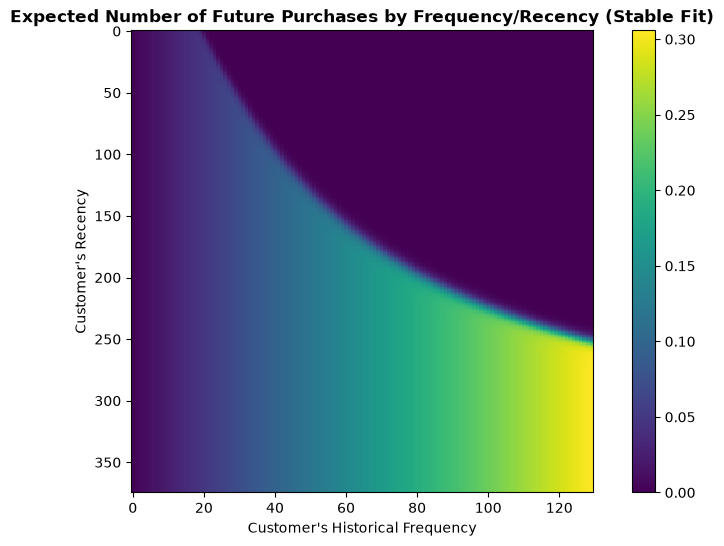

In [20]:
plt.figure(figsize=(10, 6))
plot_frequency_recency_matrix(bgf)
plt.title('Expected Number of Future Purchases by Frequency/Recency (Stable Fit)', fontweight='bold')
plt.show()

### 2.2 Discount Rate & Monetary LTV (Repeat Customers)

Gamma-Gamma was fit only on repeat customers in Step 1, and `customer_lifetime_value()` should only be called on that same population — one-time buyers have `monetary_value=0`, which violates Gamma-Gamma's assumptions if passed through here.

In [22]:
# Monthly rate for time-value-of-money adjustment. 0.01 (~1%/month, ~12.7%/year) is a
# commonly used default in both LTV literature and lifetimes' own documentation --
# treat this as a business assumption to revisit with real finance input, not a fixed constant.
MONTHLY_DISCOUNT_RATE = 0.01

repeat_customers = summary[summary['frequency'] > 0].copy()

for months in [3, 6, 12]:
    repeat_customers[f'LTV_{months}m'] = ggf.customer_lifetime_value(
        bgf,
        repeat_customers['frequency'],
        repeat_customers['recency'],
        repeat_customers['T'],
        repeat_customers['monetary_value'],
        time=months,
        freq='D',
        discount_rate=MONTHLY_DISCOUNT_RATE
    )

print("LTV distribution for repeat customers:")
display(repeat_customers[['LTV_3m', 'LTV_6m', 'LTV_12m']].describe())

LTV distribution for repeat customers:


,LTV_3m,LTV_6m,LTV_12m
count,2758.000000,2758.000000,2758.000000
mean,664.802593,1310.053441,2544.183043
std,2082.890195,4104.522898,7971.169137
min,8.101924,15.965571,31.005862
25%,158.872407,313.072401,608.000764
50%,326.085236,642.580354,1247.920115
75%,645.118640,1271.264436,2468.853041
max,58358.329185,115000.348541,223335.878937


### 2.3 Expected Transactions for the Full Customer Base

BG/NBD was fit on the entire customer base, so — unlike dollar LTV — it can still forecast an expected number of future purchases for one-time buyers, not just repeat customers. Computing it for everyone (not only the one-time-buyer subset) means the final matrix carries a purchase-count forecast for every customer, dollar estimate or not.

In [24]:
from lifetimes import ModifiedBetaGeoFitter
import warnings

# 1. Fit MBG/NBD with slight penalization
mbgf = ModifiedBetaGeoFitter(penalizer_coef=0.1)
mbgf.fit(summary['frequency'], summary['recency'], summary['T'])

# 2. Compute Expected Transactions
ltv_matrix = summary[['frequency', 'recency', 'T', 'monetary_value']].copy()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for months in [3, 6, 12]:
        days = months * 30
        ltv_matrix[f'ExpectedTransactions_{months}m'] = mbgf.conditional_expected_number_of_purchases_up_to_time(
            days, summary['frequency'], summary['recency'], summary['T']
        )

expected_cols = [f'ExpectedTransactions_{m}m' for m in [3, 6, 12]]

# Verify no NaNs exist
assert ltv_matrix[expected_cols].notna().all().all(), \
    "NaNs in expected transaction counts -- investigate before proceeding"

print("Expected future purchases (MBG/NBD) now available for full customer base:")
display(ltv_matrix[expected_cols].describe())

Expected future purchases (MBG/NBD) now available for full customer base:


,ExpectedTransactions_3m,ExpectedTransactions_6m,ExpectedTransactions_12m
count,4317.000000,4317.000000,4317.000000
mean,1.059471,2.118943,4.237886
std,1.336006,2.672011,5.344023
min,0.125398,0.250795,0.501590
25%,0.389141,0.778282,1.556564
50%,0.709142,1.418284,2.836568
75%,1.271760,2.543520,5.087040
max,27.516119,55.032238,110.064477


### 2.4 Assemble the Final Matrix

Dollar LTV only exists for repeat customers — one-time buyers get an explicit `NaN` ("unknown"), never `0` ("worth nothing").

In [26]:
ltv_matrix = ltv_matrix.merge(
    repeat_customers[['LTV_3m', 'LTV_6m', 'LTV_12m']],
    left_index=True, right_index=True, how='left'
)

n_one_time = (ltv_matrix['frequency'] == 0).sum()
print(f"One-time buyers: {n_one_time:,} customers ({n_one_time / len(ltv_matrix):.1%}) -- "
      f"get an expected-transaction forecast but no dollar LTV")
print(f"\nFinal LTV matrix: {ltv_matrix.shape[0]:,} customers x {ltv_matrix.shape[1]} columns")
print(f"Customers with a dollar LTV estimate: {ltv_matrix['LTV_12m'].notna().sum():,} "
      f"({ltv_matrix['LTV_12m'].notna().mean():.1%})")
display(ltv_matrix.head())

One-time buyers: 1,559 customers (36.1%) -- get an expected-transaction forecast but no dollar LTV

Final LTV matrix: 4,317 customers x 10 columns
Customers with a dollar LTV estimate: 2,758 (63.9%)


,frequency,recency,T,monetary_value,ExpectedTransactions_3m,ExpectedTransactions_6m,ExpectedTransactions_12m,LTV_3m,LTV_6m,LTV_12m
CustomerID,,,,,,,,,,
12347,6.0,365.0,368.0,599.701667,1.419478,2.838956,5.677911,838.779401,1652.890425,3209.987974
12348,3.0,283.0,359.0,261.480000,0.790361,1.580721,3.161443,206.343400,406.618272,789.671078
12349,0.0,0.0,19.0,0.000000,0.771812,1.543625,3.087250,NaN,NaN,NaN
12350,0.0,0.0,311.0,0.000000,0.147289,0.294579,0.589158,NaN,NaN,NaN
12352,6.0,260.0,297.0,181.540000,1.710031,3.420061,6.840123,308.118296,607.174878,1179.161078


### 2.5 Sanity Checks & Distribution

A couple of checks that should always hold if the pipeline is behaving: LTV can't be negative, and 12-month LTV can never be lower than 6-month LTV for the same customer.

In [28]:
assert (ltv_matrix['LTV_3m'].dropna() >= 0).all(), "Negative LTV found -- investigate before proceeding"
assert (ltv_matrix['LTV_12m'].dropna() >= ltv_matrix['LTV_6m'].dropna()).all(), \
    "12-month LTV should never be lower than 6-month LTV for the same customer"

print("Top 10 customers by predicted 12-month LTV:")
display(ltv_matrix.sort_values('LTV_12m', ascending=False).head(10))

predicted_12m_revenue = ltv_matrix['LTV_12m'].sum()
historical_total_revenue = df['TotalRevenue'].sum()
print(f"\nTotal predicted 12-month revenue (repeat customers): ${predicted_12m_revenue:,.2f}")
print(f"Historical total revenue (entire dataset, ~13 months): ${historical_total_revenue:,.2f}")
print("(Not directly comparable -- historical includes one-time buyers' actual past spend, while "
      "predicted is forward-looking for repeat customers only. But if predicted revenue were, say, "
      "5x higher than total historical revenue, that's a red flag worth investigating, not reporting "
      "at face value.)")

Top 10 customers by predicted 12-month LTV:


,frequency,recency,T,monetary_value,ExpectedTransactions_3m,ExpectedTransactions_6m,ExpectedTransactions_12m,LTV_3m,LTV_6m,LTV_12m
CustomerID,,,,,,,,,,
14646,43.0,353.0,355.0,6141.472093,9.689997,19.379993,38.759987,58358.329185,115000.348541,223335.878937
18102,25.0,367.0,368.0,8773.308400,5.511697,11.023395,22.046789,47428.904719,93462.932366,181509.242474
14096,16.0,97.0,102.0,3327.985000,9.832024,19.664049,39.328097,32107.159778,63270.052737,122873.304452
14911,129.0,372.0,374.0,1048.798062,27.516119,55.032238,110.064477,28296.071137,55759.959007,108288.362708
12415,14.0,313.0,338.0,8032.607857,3.385580,6.771159,13.542318,26684.725774,52584.657709,102121.783952
17450,26.0,359.0,368.0,4405.333462,5.727077,11.454154,22.908309,24746.807910,48765.815860,94705.420333
14156,42.0,362.0,372.0,2757.968571,9.086180,18.172360,36.344719,24575.604409,48428.443928,94050.228782
17511,27.0,371.0,374.0,3297.238519,5.858339,11.716679,23.433357,18946.872792,37336.520859,72509.212434
16684,14.0,354.0,359.0,4374.112857,3.211691,6.423382,12.846764,13785.858394,27166.276731,52758.138285



Total predicted 12-month revenue (repeat customers): $7,016,856.83
Historical total revenue (entire dataset, ~13 months): $8,030,922.53
(Not directly comparable -- historical includes one-time buyers' actual past spend, while predicted is forward-looking for repeat customers only. But if predicted revenue were, say, 5x higher than total historical revenue, that's a red flag worth investigating, not reporting at face value.)


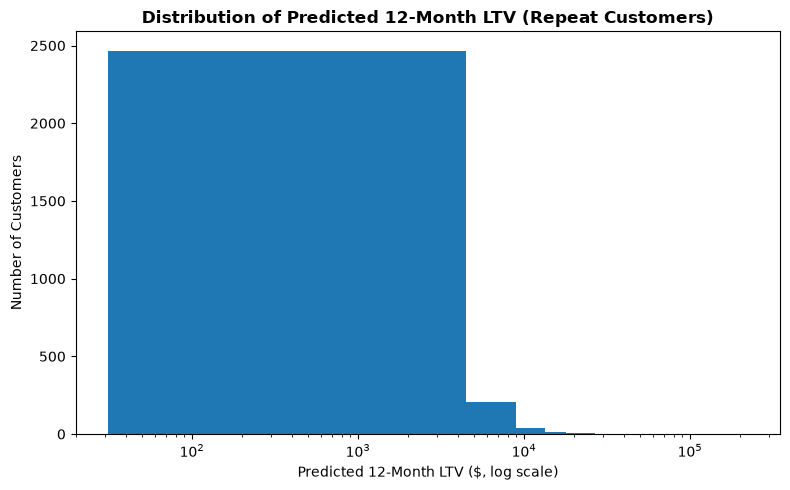

In [29]:
# LTV is heavily right-skewed (a handful of high-value customers), so a log-scale histogram
# shows the shape far better than a linear one would
plt.figure(figsize=(8, 5))
plt.hist(ltv_matrix['LTV_12m'].dropna(), bins=50, color='#1f77b4')
plt.xscale('log')
plt.xlabel('Predicted 12-Month LTV ($, log scale)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Predicted 12-Month LTV (Repeat Customers)', fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 Save for Phase 5

Written out as a parquet file so the dashboard phase can load it directly instead of re-running the model fits.

In [31]:
ltv_matrix.to_parquet('ltv_matrix.parquet')
print(f"Saved ltv_matrix.parquet -- {ltv_matrix.shape[0]:,} customers x {ltv_matrix.shape[1]} columns")

Saved ltv_matrix.parquet -- 4,317 customers x 10 columns


## Conclusions & Business Recommendations

**Model validity.** The calibration/holdout check (Step 1) shows BG/NBD's purchase-timing forecasts track actual holdout behavior reasonably well. The `a`/`b` dropout parameters remain weakly identified even after stabilizing the fit — a real characteristic of this dataset (~36% one-time buyers) rather than a modeling mistake — so individual "probability this specific customer is still active" estimates deserve more skepticism than the aggregate expected-transaction and LTV numbers, which the holdout validation directly supports.

**Revenue is concentrated in a small group.** The 12-month LTV distribution is heavily right-skewed — a log-scale histogram was needed just to see its shape, and the top 10 customers by predicted LTV are worth roughly 40–180x the median repeat customer (compare the top-10 table to the median row in the `.describe()` output above). That's a Pareto-style pattern worth acting on directly: a retention or account-management program aimed at even the top 1-2% of predicted LTV would cover a disproportionate share of forecast revenue.

**How this could be used:** `ltv_matrix` combined with the Phase 3 churn probabilities gives a natural prioritization for a retention team — high predicted LTV *and* high churn risk is the segment to protect first, versus a low-LTV customer who churns (lower priority) or a high-LTV customer with low churn risk (no action needed yet). That combined view is a good candidate for the Phase 5 dashboard rather than this notebook.

**Limitations & possible next steps:**
- `a`/`b` remain weakly identified; `ModifiedBetaGeoFitter` is worth trying if a future analysis specifically needs individual-customer "probability alive" estimates rather than aggregate LTV.
- The 1%/month discount rate is a placeholder business assumption, not a finance-team-supplied figure.
- The 90-day calibration/holdout split and the "30 days ≈ 1 month" approximation are both reasonable but simplifying choices worth revisiting if the business's actual purchase cadence differs.
- No segment-level breakdown (e.g., by the Phase 2 RFM segments) has been done yet — comparing average LTV across segments would be a natural bridge to the dashboard phase.

In [33]:
ltv_matrix.reset_index().to_parquet('../data/processed/ltv_matrix.parquet', index=False)
print(f"Saved LTV matrix for {ltv_matrix.shape[0]:,} customers.")

Saved LTV matrix for 4,317 customers.
